## Analisi e ClassiAnalisi e Classificazione delle Email per la Rilevazione di SPAM
ProfessionAI, azienda specializzata nell'automazione basata sull'Intelligenza Artificiale, vuole sviluppare una libreria software in grado di analizzare e classificare le email ricevute. L'obiettivo principale è identificare le email di tipo SPAM per condurre successivamente delle analisi approfondite sui contenuti.

Il CEO ha espresso l'esigenza di focalizzarsi su email SPAM per comprendere meglio le tendenze, i contenuti e i comportamenti associati. Queste informazioni verranno utilizzate per migliorare la sicurezza delle comunicazioni aziendali e perfezionare i filtri anti-spam.

<br>

### Obiettivi del Progetto
Il CTO ha fornito un dataset di email per realizzare le seguenti attività:

- Addestrare un classificatore per identificare le email SPAM;
- Individuare i Topic principali tra le email classificate come SPAM;
- Calcolare la distanza semantica tra i topics ottenuti per valutare l'eterogeneità dei contenuti delle email SPAM;
- Estrarre dalle email NON SPAM le informazioni sulle Organizzazioni menzionate.

<br>

### Valore Aggiunto
L'analisi delle email permette a ProfessionAI di ottenere diversi vantaggi strategici:

- Miglioramento del filtro anti-spam: Un classificatore efficiente permette di ridurre significativamente il volume di email indesiderate che raggiungono la casella di posta, ottimizzando la gestione delle comunicazioni aziendali;
- Analisi contenutistica approfondita: L'individuazione dei principali topic trattati nelle email SPAM consente di ottenere informazioni preziose sui trend, tematiche e schemi ricorrenti, potenziando le strategie di cybersecurity;
- Valutazione dell'eterogeneità: La distanza semantica tra i topic consente di comprendere la diversità dei contenuti SPAM, utile per ottimizzare le difese contro un'ampia gamma di attacchi;
- Identificazione di organizzazioni: L'estrazione di organizzazioni dalle email legittime può essere sfruttata per migliorare i processi di business intelligence e gestire meglio le comunicazioni con clienti e partner.

<br>

### Conclusione
Il progetto offrirà a ProfessionAI un'analisi completa delle email ricevute, con particolare focus sull'identificazione delle email SPAM e l'analisi dei loro contenuti. Grazie alla segmentazione dei topic e all'analisi semantica, l'azienda potrà migliorare significativamente i propri filtri anti-spam e ottenere insight sui contenuti di maggiore rilevanza, nonché ottimizzare la gestione delle comunicazioni aziendali tramite l'estrazione di informazioni chiave dalle email legittime.

Questa soluzione incrementerà la sicurezza delle comunicazioni e migliorerà i processi decisionali aziendali, generando un vantaggio competitivo nel settore.

#### Import delle librerie
Di seguito iniziamo a importare tutte le librerie necessarie alla costruzione del filtro.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re, random
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample
from keras.layers import BatchNormalization
from gensim import corpora, models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import nltk

#### 1) Data Exploration
In questa fase iniziale, analizziamo il file CSV di input contenente la lista dei commenti associati alla rispettiva classificazione spam o no spam. L’obiettivo è comprendere la struttura dei dati al fine di applicare le opportune tecniche di data cleaning e data preparation, propedeutiche all’addestramento del modello.

In [4]:
#CSV exploration
url = 'spam_dataset.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


Notiamo che la struttura del dataset è abbastanza semplice: una variabile "text" contiene il rispettivo commento mentre la variabile numerica "label_num" è valorizzata a 1 se il commento associato è spam e 0 altrimenti. Notiamo inoltre, già da queste prime cinque righe, che i commenti contengono caratteri speciali, numeri e altre componenti non utili ai fini del training. Applicheremo in seguito opportune tecniche di cleaning.

In [3]:
#Usando la info() function, proviamo a vedere se esistono valori a missing:
print(f"{df.info()}")
print(f"Struttura del dataset: righe {df.shape[0]}, colonne {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB
None
Struttura del dataset: righe 5171, colonne 4


Notiamo che su 5171 colonne complessive, nessuna ha valori a missing.

In [8]:
#Analisi delle label
conteggio = df['label_num'].value_counts()
print(conteggio)
print(f"Percentuale di commenti spam:{1499/5171}")
print(f"Percentuale di commenti non spam:{3672/5171}")

0    3672
1    1499
Name: label_num, dtype: int64
Percentuale di commenti spam:0.2898859021465867
Percentuale di commenti non spam:0.7101140978534133


In [ ]:
#Notiamo che la distribuzioni di spam e non spam è tra il 30 e il 70 percento; questa proporzione è buona 
#per la costruzione di un modello. Pertanto, per ora, non adotteremo tecniche di sampling sul dataset. 

#### 2) Data Preparation
La fase di data preparation può essere riassunta nei seguenti step principali. Partendo dal dataset contenente i vari commenti, procederemo seguendo questa metodologia:

Data Cleaning: rimozione di eventuali caratteri speciali, riduzione a stessa formatazzione;
Tokenizzazione: trasformare il testo in sequenze di numeri interi;
Padding: padding delle sequenze per ottenere una lunghezza uniforme.

#### 2.2) Gestione dei caratteri speciali

In [11]:
#Formattazione dei commenti: cerchiamo di eliminare eventuali caratteri speciali. Possiamo usare
#le regex function.

def clean_text(text):
    text = text.lower()#Conversione di ogni commento in minuscolo
    text = re.sub(r"(?<!\w)'(?!\w)", "", text)#Rimozione di apostrofi non significativi
    text = re.sub(r'\s+', ' ', text).strip()#Rimozione di evenutali spazi multipli
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)#Rimozione caratteri non latini
    
    #Seleziona solo frasi con più di un carattere (filtra frasi troppo brevi)
    sentences = re.findall(r'[^.?!\n]+', text)#Trova le frasi
    
    #Filtra le frasi troppo corte
    sentences = [sentence.strip() for sentence in sentences if len(sentence.strip()) > 1]
    
    #Uniamo le frasi filtrate in un unico testo
    text = ' '.join(sentences)
    return text

#Applichiamo la function ai commenti
df['text'] = df['text'].apply(clean_text)

In [13]:
#Check post cleaning
print(df['text'].iloc[100:120])

100    subject help  brian  who do i talk to about ge...
101    subject fw  ena origination track      origina...
102    subject password reset this is a generated ema...
103    subject lose 19   powerful weightloss now avai...
104    subject 80                    smart ink system...
105    subject woops     on beaumont methanol  i made...
106    subject buy pain relief medicine at unbelievab...
107    subject nom for 2  16  00 we are increasing th...
108    subject 7 th noms                       forwar...
109    subject about celebration ready  decide eye  h...
110    subject cialis  valium  viagra  xanax at low p...
111    subject cox exploration darren  we had a situa...
112    subject february and march 2000 meter 5688 fre...
113    subject mitchell gas services 2  00           ...
114    subject kcs resources nom  april 1 the nom for...
115    subject young pussies tonya could feel the glo...
116    subject settelement request for an equistar  b...
117    subject re  lindholm oil

#### 2.3) Tokenizzazione
Nei modelli di elaborazione del linguaggio naturale, questa fase consiste nel trasformare il testo grezzo in unità comprensibili per il modello. Si inizia a dividere ogni testo (nel nostro caso ogni commento) in parole (unità) a cui si associa un numero univoco che andrà a popolare un rispettivo dizionario. Il processo terminerà con una fase, detta di padding, dove le varie sequenze verranno uniformate a una lunghezza prefissata per essere compatibili con il modello. Per effettuare queste fasi utilizzeremo tool appositi presi dalla libreria tensorflow.

In [15]:
#1)Selezione del testo (ovvero dei commenti del csv) e delle rispettive labels. La variabile categories
#contiene l'elenco delle colonne che descrivono la tipologia di commento
texts = df['text'].values
labels = df['label_num'].values

Per la fase di tokenizzazione che segue, impostiamo il parametro OOV. In questo modo, ogni parola che non rientra tra le prime max_words più comuni (o che non è presente nel vocabolario) verrà automaticamente sostituita con il token oov. Quando si adotta il metodo texts_to_sequences, tutte le parole non presenti nel dizionario verranno mappate all'indice del token oov. Il token oov verrà assegnato a un indice durante il processo di fit_on_texts, tipicamente il primo indice (ad esempio 1), a meno che non siano presenti altre configurazioni. E' preferibile impostare questo parametro poichè altrimenti le parole sconosciute non verranno rappresentate in alcun modo, risultando in una sequenza più corta e potenzialmente distorta rispetto al testo originale. Senza tale parametro si potrebbe intercorrere in problemi di generalizzazione e perdita di informazione in fase modellistica.

In [19]:
#2)Tokenizer: creazione dell'oggetto token
max_words = 5000
tokenizer = Tokenizer(num_words = max_words, oov_token="<oov>")

#---> #Prime 5000 più comuni per la creazione del dizionario

#Uso della fit_on_texts: analisi di tutti i commenti per creare il dizionario (word_index) che 
#associerà in modo univoco ogni parola a un numero intero.
tokenizer.fit_on_texts(texts)

In [20]:
#Check delle parole complessive nel dizionario
num_words_in_dict = len(tokenizer.word_index)
print(f"Numero totale di parole nel dizionario: {num_words_in_dict}")

Numero totale di parole nel dizionario: 50523


In [21]:
#Visualizza le prime 10 parole più frequenti nel dizionario
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"Parola: {word}, Indice: {index}")

Parola: <oov>, Indice: 1
Parola: the, Indice: 2
Parola: to, Indice: 3
Parola: ect, Indice: 4
Parola: and, Indice: 5
Parola: for, Indice: 6
Parola: of, Indice: 7
Parola: a, Indice: 8
Parola: you, Indice: 9
Parola: subject, Indice: 10


In [22]:
#Check sulla percentuale di copertura: le 5000 parole scelte sono sufficienti?

#1)Frequenze delle parole nel dizionario
word_counts = tokenizer.word_counts  # Dizionario: parola -> frequenza

#2)Somma delle frequenze delle parole considerate e totale
top_words_freq = sum(freq for word, freq in word_counts.items() if tokenizer.word_index[word] <= 5000)
total_freq = sum(word_counts.values())

#3)Percentuale di copertura
coverage = (top_words_freq / total_freq) * 100
print(f"Le prime 5.000 parole coprono il {coverage:.2f}% del corpus totale.")

Le prime 5.000 parole coprono il 88.07% del corpus totale.


Dato che le prime 5000 parole comprono all'incirca il 90% del corpo totale dei testi, optiamo a mantenere il valore 5000.

In [23]:
#texts_to_sequences: conversione di ogni commento in una sequenza di numeri tramite il dizionario per
#la successiva fase di padding
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

In [27]:
#Check su un commento
n = 124
print(f"Frase 1: {texts[n]}")
print(f"Tokenizer vector per frase 1: {sequences[n]}")

Frase 1: subject the bast phharma out ther  same da  y shijpping  chromium hi  this is for sure one of the best pahrma we can offer you  we can give special deels and more  just enter the pharmma now  don t hesitate alb nah cloy cloven crossword blank compote centrex  assumption chump babbitt chinchilla  cauldron calvary bobby aspirant aspect  apotheosis cameraman alluvium conclusion  agglomerate bergland consular choreography caracas  arsine bandpass carlyle  confident buzzer combine  commemorate assignee crinkle biscuit antiperspirant  coalesce amphioxis biddy baseman arrack  bashful aloe al  alcoa assyria bottommost abreast buzzing d etat  camel billiard bland cufflink
Tokenizer vector per frase 1: [10, 2, 1, 1, 93, 1, 313, 2406, 681, 1, 1, 585, 15, 14, 6, 369, 121, 7, 2, 296, 1, 21, 55, 449, 9, 21, 55, 362, 435, 1, 5, 119, 150, 822, 2, 1, 146, 204, 74, 2857, 1, 1, 1, 1, 1, 2412, 1, 1, 1, 1, 1, 1, 1, 1, 2521, 1, 4326, 1, 1, 1, 3934, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

#### 2.4) Padding
La funzione pad_sequences è utilizzata per garantire che tutte le sequenze di parole (dopo la tokenizzazione) abbiano la stessa lunghezza dato che le LSTM o GRU richiedono input di dimensioni costanti. In presenza di sequenze con lunghezza diversa, la pad_sequences le riempie con 0 (di default) per renderle tutte della stessa lunghezza, che si può definire tramite il parametro maxlen. Per la determinazione del parametro ottimale, optiamo per la seguente strategia: proviamo a studiare la distribuzione delle frequenze assolute delle lunghezze dei singoli commenti.

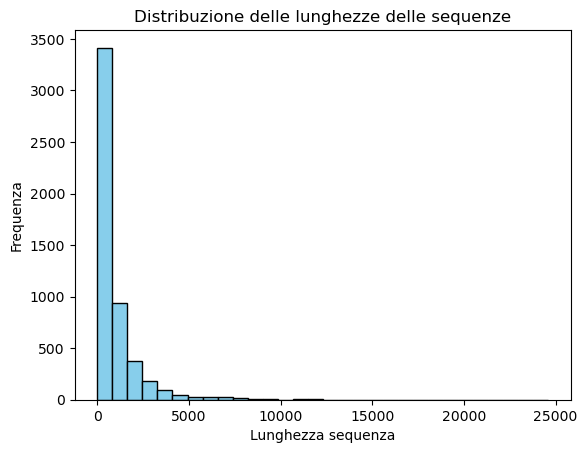

In [30]:
#Determinazione max_sequence_length e successiva applicazione

#Calcolo delle lunghezze
sequence_lengths = [len(seq) for seq in texts]

#Creazione di un istogramma di frequenze assolute
plt.hist(sequence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuzione delle lunghezze delle sequenze')
plt.xlabel('Lunghezza sequenza')
plt.ylabel('Frequenza')
plt.show()

La distribuzione sembra quella di una legge esponenziale. Per la determinazione del parametro ottimale di lunghezza (max_sequence_length) optiamo per il'80-esimo percentile della distribuzione.

In [33]:
#max_sequence_length (80-esimo percentilie)
max_sequence_length = np.percentile(sequence_lengths, 80)
print(f"max_sequence_length: {int(max_sequence_length)}")

max_sequence_length: 1366


In [34]:
#Padding: applicazione del padding col valore ottimale: in base all'osservazione precedente optiamo
#per una valore pari a 1400
max_sequence_length = 1400
data_padded = pad_sequences(sequences, maxlen = max_sequence_length)

### 3) Approcci modellistici
In questa sezione proveremo a implementare una LSTM.

#### 3.1) Modellizzazione della rete neurale
Terminata la fase di data preparation, possiamo passare alla costruzione della LSTM. A tal proposito, adotteremo le funzionalità delle librerie tensorflow e keras.

<br>

#### Architettura della LSTM
L'architettura della LSTM che andremo a costruire prevederà la presenza di 6 layers:

<br>

- Layer 1 (Embedding): questo primo layer trasforma gli indici interi delle parole (ottenuti nella fase di tokenizzazione) in vettori densi di dimensione fissa;
- Layer 2 (LSTM): elaborazione delle sequenze mantenendo informazioni di lungo termine grazie alla sua struttura ricorrente, uso di 64 neuroni nel layer, valorizzazione a True per connettersi al LSTM layer successivo;
- Layer 3 (BatchNormalization): può essere utile tra i layer LSTM e dopo il layer Dense per stabilizzare il training;
- Layer 4 (Dropout): livello intermedio per riduzione di eventuali overfitting;
- Layer 5 (LSTM): secondo LSTM layer;
- Layer 6 (BatchNormalization)
- Layer 7 (Dropout): un secondo livello intermedio per riduzione di eventuali overfitting;
- Layer 8 (Dense): essendo un problema di classificazione binario, per il layer finale optiamo a un layer che preveda come funzione di attivazione una sigmoide.

<br>

Per ora ci baseremo su questa struttura; chiaramente, può sempre essere ottimizzata aggiungendo più layers nello strato nascosto.

NB: è buona prassi applicare una clear_session() prima del lancio di una nuova rete in fase di testing.

In [46]:
#LSTM architettura neurale: il parametro max_words corrisponde al numero massimo di parole del vocabolario
K.clear_session()

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [47]:
#Check sull'architettura neurale
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 1400, 128)         640000    
                                                                 
 lstm (LSTM)                 (None, 1400, 64)          49408     
                                                                 
 batch_normalization (BatchN  (None, 1400, 64)         256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1400, 64)          0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                        

#### 3.2) Training,Test & Validation set
Di seguito costruiamo i vari sottoinsiemi del dataset necessari al training e alla validazione del modello. Da richieste progettuali, si richiede anche la costruzione di un test set finale su cui verificare ulteriormente la bontà del modello costruito. Nello specifico, possiamo riassumere il tutto nei seguenti step:

<br>

- 1) costruzione del training set per addestrare il modello;
- 2) costruzione del validation set: utilizzato per ottimizzare i parametri del modello e monitorare l'overfitting durante l'addestramento;
- 3) costruzione del test set: usato per valutare le performance finali del modello su dati mai visti.

In [48]:
#Training e test set: 30% dei dati assegnato al test set. Inoltre, per le label, bisogna creare 
#una vettorizzazione essendo un problema di classificazione multilabel
X = data_padded
y = df[['label_num']].values
X.shape#Check dimensioni

(5171, 1400)

In [49]:
#Step 1: divisione iniziale in due set: il primo servirà per venire poi risuddiviso in training e
#e validation set (X_temp e y_temp) mentre la seconda parte servirà come test set (X_test, y_test). 
#Il test set corrisponderà al 20% del dataset complessivo. 
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 2: divisione in training e validation per il training del modello (divideremo dal X_temp e y_temp).
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42)

#Check dimensioni
print(f"Dimensione Training Set: {len(X_train)}")
print(f"Dimensione Validation Set: {len(X_val)}")
print(f"Dimensione Test Set: {len(X_test)}")

Dimensione Training Set: 2895
Dimensione Validation Set: 1241
Dimensione Test Set: 1035


#### Model compile
Di seguito compiliamo il modello tramite il comando compile. Nello specifico, adotteremo la tecnica
di ottimizzazione ADAM (Adaptive Moment Estimation). Ricordiamo alcuni vantaggi di questa tecnica:

* Momentum: riduce le oscillazioni nei minimi locali grazie al mantenimento di una media ponderata dei gradienti passati;
* RMSprop: adatta il tasso di apprendimento per ciascun parametro in base alla media quadratica dei gradienti recenti, rendendo l'aggiornamento robusto e adattivo.

#### Scelta della funzione di loss
Come funzione di loss optiamo per la binary crossentropy; essendo di fronte a un problema multilabel,
tale funzione risulta ottimale allo scopo, in particolare:

* adatta per problemi multilabel: nel nostro caso abbiamo 6 classificazioni, ciascuna indipendente. La BCE funziona bene per problemi multilabel poiché valuta separatamente la previsione di ciascuna etichetta;
* compatibilità con la sigmoide nello strato finale: l'output della funzione sigmoide produce valori tra 0 e 1, perfetti per BCE;
* la BCE è una funzione differenziabile, pertanto è ben supportata dall'ottimizzazione Adam.

In [51]:
#Compilazione della LSTM: uso della binary_crossentropy, più adatta per un problema multilabel
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall', 'AUC'])#Monitoraggio delle metriche

In [52]:
#Costruzione di una tecnica di early stopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss',#Quale metrica monitorare per l'overfitting
                               patience=3,#Permette al modello di continuare per 3 epoche senza migliorare prima di fermarsi
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=2, 
                              min_lr=1e-6)#Impedisce che il learning rate diventi troppo piccolo

In [53]:
#Training del modello
history = model.fit(X_train, y_train, batch_size=64,
                    epochs=5, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/5
46/46 [==============================] - 250s 5s/step - loss: 0.2468 - accuracy: 0.9116 - precision: 0.8248 - recall: 0.8819 - auc: 0.9667 - val_loss: 0.5059 - val_accuracy: 0.9549 - val_precision: 0.9727 - val_recall: 0.8723 - val_auc: 0.9926 - lr: 0.0020
Epoch 2/5
46/46 [==============================] - 243s 5s/step - loss: 0.0519 - accuracy: 0.9865 - precision: 0.9717 - recall: 0.9821 - auc: 0.9980 - val_loss: 0.3157 - val_accuracy: 0.9533 - val_precision: 0.8799 - val_recall: 0.9755 - val_auc: 0.9942 - lr: 0.0020
Epoch 3/5
46/46 [==============================] - 288s 6s/step - loss: 0.0306 - accuracy: 0.9907 - precision: 0.9856 - recall: 0.9821 - auc: 0.9994 - val_loss: 0.2474 - val_accuracy: 0.9267 - val_precision: 0.8031 - val_recall: 0.9973 - val_auc: 0.9968 - lr: 0.0020
Epoch 4/5
46/46 [==============================] - 244s 5s/step - loss: 0.0116 - accuracy: 0.9972 - precision: 0.9952 - recall: 0.9952 - auc: 0.9999 - val_loss: 0.1799 - val_accuracy: 0.9452 - val_pr

In [54]:
#Costruzione della curve di learning: costruzione delle liste necessarie
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_precision = history.history['precision']
val_precision = history.history['val_precision']

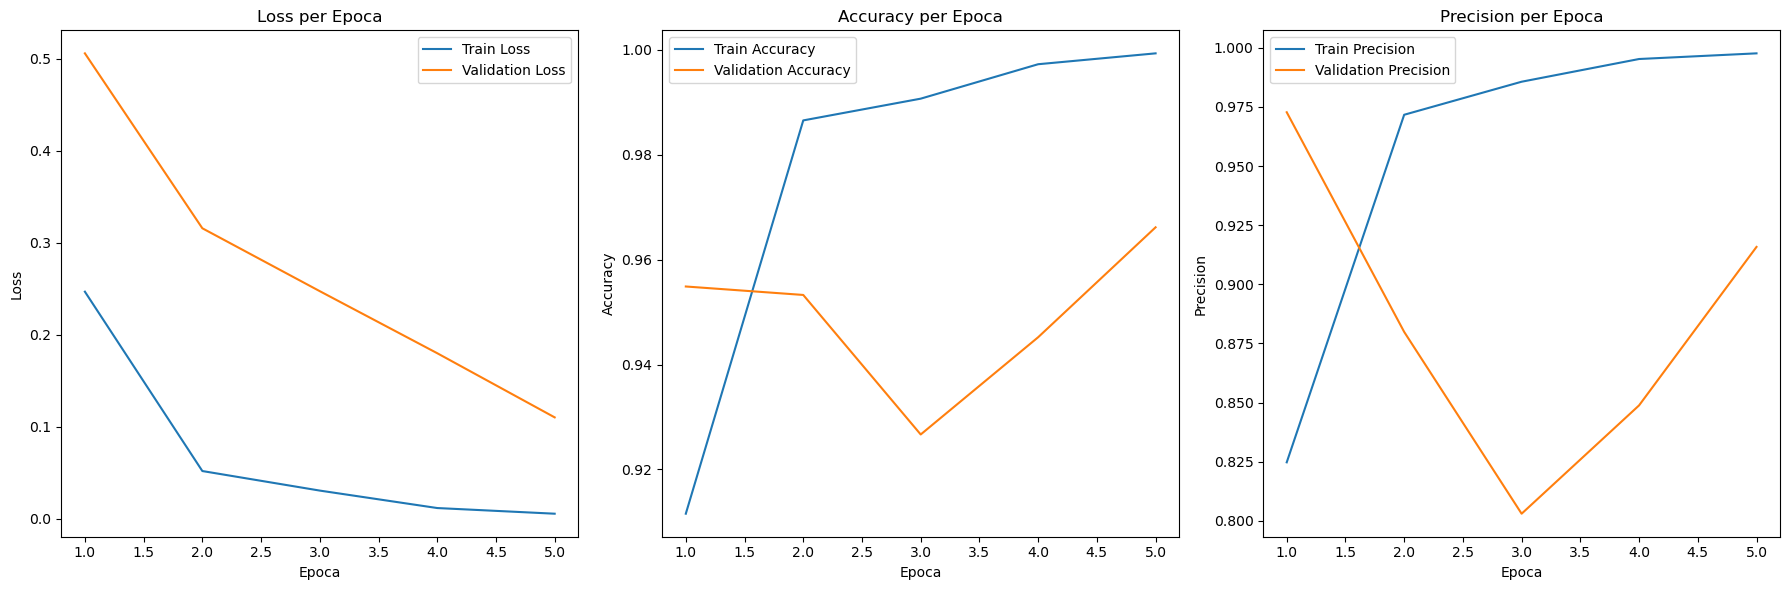

In [55]:
#Plot delle learning curves
plt.figure(figsize=(18, 6))

#A) Curva della Loss
plt.subplot(1, 3, 1)  # Cambiato a 1x3 per fare spazio alla Precisione
plt.plot(range(1, 6), train_loss, label='Train Loss')
plt.plot(range(1, 6), val_loss, label='Validation Loss')
plt.title('Loss per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

#B) Curva dell'Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 6), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 6), val_accuracy, label='Validation Accuracy')
plt.title('Accuracy per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

#C) Curva della Precision
plt.subplot(1, 3, 3)
plt.plot(range(1, 6), train_precision, label='Train Precision')
plt.plot(range(1, 6), val_precision, label='Validation Precision')
plt.title('Precision per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()

#Grafico finale
plt.tight_layout()
plt.show()

In [56]:
#Test del modello sui dati di validazione (che corrispondeva al 30% del dataset)
results = model.evaluate(X_test, y_test)
print("Test Loss:", results[0])  # Il primo valore è la loss
print("Test Accuracy:", results[1])  # Il secondo valore è l'accuracy
print("Test Precision:", results[2])  # Se precision è la terza metrica
print("Test Recall:", results[3])  # Se recall è la quarta metrica
print("Test AUC:", results[4])  # Se auc è la quinta metrica

33/33 [==============================] - 22s 671ms/step - loss: 0.1075 - accuracy: 0.9729 - precision: 0.9260 - recall: 0.9829 - auc: 0.9950
Test Loss: 0.10746128112077713
Test Accuracy: 0.9729468822479248
Test Precision: 0.9260450005531311
Test Recall: 0.9829351305961609
Test AUC: 0.9949564337730408


In [57]:
#Salvataggio del modello (NB. h5 è un formato di salvataggio tipico per salvare modelli di deep learning)
model.save("lstm_model_1_spam_classifier")

#Riutilizzo del modello: in caso di riutilizzo, si può richiamare il modello salvato senza dovero
#riaddestrare tutto da capo. Il formato h5 tiene conto dell'architettura della rete e di tutti i
#dettagli intrischi dall'applicazione della compile function.
from tensorflow.keras.models import load_model
model_loaded = load_model("lstm_model_1_spam_classifier")

INFO:tensorflow:Assets written to: lstm_model_1_spam_classifier\assets


INFO:tensorflow:Assets written to: lstm_model_1_spam_classifier\assets


### LDA
In questa sezione cerchiamo di costruire una metodologia in grado di estrarre i topic principali dalle mail del dataset considerate come spam. La tecnica che adotteremo sarà quella della LDA (Latent Dirichlet Allocation). L'idea di fondo della LDA è di andare a determinare K topic nascosti sotto l'ipotesi che ogni topic sia una distribuzione di parole e che ogni documento sia un combinazione di uno o più topic. Nello specifico, la distribuzione di parole associata a ogni topic è campionata da una Dirichlet.

In [5]:
#Consideriamo solo le mail spam del dataset
spam_emails = df[df['label_num'] == 1]['text'].tolist()

In [6]:
nltk.download('punkt')
nltk.download('stopwords')

#Funzione di preprocessing
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stopwords.words('english') and t not in string.punctuation]
    return tokens

processed_emails = [preprocess(email) for email in spam_emails]

#Dizionario e corpus
dictionary = corpora.Dictionary(processed_emails)
corpus = [dictionary.doc2bow(email) for email in processed_emails]

#Sintassi per costruire la LDA
n = 5
lda_model = models.LdaModel(corpus, num_topics=n, id2word=dictionary, passes=10)

#Individuazione dei topic global tramite la LDA
topics = lda_model.print_topics(num_words=5)
for idx, topic in topics:
    print(f"Topic {idx + 1}: {topic}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Costa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Costa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 1: 0.013*"td" + 0.011*"http" + 0.010*"height" + 0.010*"font" + 0.008*"width"
Topic 2: 0.013*"subject" + 0.006*"http" + 0.005*"com" + 0.005*"get" + 0.005*"pills"
Topic 3: 0.020*"3" + 0.008*"com" + 0.008*"subject" + 0.006*"4" + 0.006*"computron"
Topic 4: 0.010*"company" + 0.008*"statements" + 0.005*"nbsp" + 0.005*"information" + 0.005*"price"
Topic 5: 0.005*"``" + 0.005*"subject" + 0.003*"2" + 0.003*"3" + 0.002*"1"


In [10]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Prepara i dati per la visualizzazione
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)

# Visualizza nel notebook o browser
pyLDAvis.show(vis_data)  # Apre nel browser

SyntaxError: invalid syntax (3068640725.py, line 1)